In [1]:
!pip install pandas numpy scikit-learn tensorflow seaborn matplotlib

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

In [3]:
urls_df = pd.read_csv("dataset/training.csv")

print("Original columns:", urls_df.columns.tolist())
print(urls_df.head())
print("\nValue counts in 'type' column:")
print(urls_df['type'].value_counts())

Original columns: ['url', 'type']
                         url        type
0     https://www.google.com  legitimate
1    https://www.youtube.com  legitimate
2   https://www.facebook.com  legitimate
3      https://www.baidu.com  legitimate
4  https://www.wikipedia.org  legitimate

Value counts in 'type' column:
type
legitimate    345738
phishing      104438
Phishing       54805
Name: count, dtype: int64


In [4]:
urls_df['label'] = urls_df['type'].apply(lambda x: 0 if x.lower() == 'phishing' else 1)
urls_df = urls_df[['url', 'label']].dropna()
urls_df = urls_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nFinal dataset shape:", urls_df.shape)
print(urls_df['label'].value_counts())
print("\nSample data:")
print(urls_df.head())


Final dataset shape: (504981, 2)
label
1    345738
0    159243
Name: count, dtype: int64

Sample data:
                                                 url  label
0  https://www.highschoolsticking.lohudblogs.com/...      1
1              https://lihi.cc/mbmSd?goto=GR9BOQLEB1      0
2  https://www.discogs.com/artist/Pebbles?anv=Per...      1
3  http://www.ege-sel.com/wp-blog/adm/index.php?m...      0
4  http://www.wuzhou-my.com/images/?us.battle.net...      0


In [5]:
train_urls, val_urls, train_labels, val_labels = train_test_split(
    urls_df['url'],
    urls_df['label'],
    test_size=0.2,
    stratify=urls_df['label'],
    random_state=42
)

y_train = np.array(train_labels)
y_val = np.array(val_labels)

In [6]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,3))
X_train_tfidf = tfidf.fit_transform(train_urls)
X_val_tfidf = tfidf.transform(val_urls)

In [7]:
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=200)

In [8]:
svm_model = LinearSVC(C=0.5)
svm_model.fit(X_train_tfidf, y_train)

LinearSVC(C=0.5)

In [9]:
max_length = 120

tokenizer = Tokenizer(char_level=True, num_words=2000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_urls)

X_train = pad_sequences(tokenizer.texts_to_sequences(train_urls), maxlen=max_length, padding='post')
X_val = pad_sequences(tokenizer.texts_to_sequences(val_urls), maxlen=max_length, padding='post')

vocab_size = len(tokenizer.word_index) + 1


In [10]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

In [11]:
cnn_model = Sequential([
    Embedding(vocab_size, 64),
    Conv1D(64, 3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1,
    batch_size=256
)

1579/1579 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9833 - loss: 0.0663 - precision: 0.9822 - recall: 0.9937 - val_accuracy: 0.9930 - val_loss: 0.0289 - val_precision: 0.9928 - val_recall: 0.9969


In [12]:
class Attention(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer="normal")
        self.b = self.add_weight(shape=(input_shape[1], 1),
                                 initializer="zeros")
        super().build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

In [13]:
bilstm_model = Sequential([
    Embedding(vocab_size, 256),

    Conv1D(128, 5, activation='relu', padding='same'),
    BatchNormalization(),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),

    Attention(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.0007)

bilstm_model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

bilstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1,
    batch_size=256,
    class_weight=class_weights
)

1579/1579 ━━━━━━━━━━━━━━━━━━━━ 100s 57ms/step - accuracy: 0.9919 - loss: 0.0343 - precision_1: 0.9946 - recall_1: 0.9936 - val_accuracy: 0.9944 - val_loss: 0.0205 - val_precision_1: 0.9967 - val_recall_1: 0.9951


In [14]:
def evaluate(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    )

def evaluate_dataset(file_path, name):
    df = pd.read_csv(file_path)
    df = df[["URL", "ClassLabel"]].dropna()

    urls = df["URL"]
    y = df["ClassLabel"].astype(int).values

    X_tfidf = tfidf.transform(urls)
    lr_pred = lr_model.predict(X_tfidf)
    svm_pred = svm_model.predict(X_tfidf)

    X_seq = pad_sequences(tokenizer.texts_to_sequences(urls), maxlen=max_length, padding='post')

    cnn_pred = (cnn_model.predict(X_seq) > 0.5).astype(int).flatten()
    bilstm_pred = (bilstm_model.predict(X_seq) > 0.5).astype(int).flatten()

    return {
        "name": name,
        "lr": evaluate(y, lr_pred),
        "svm": evaluate(y, svm_pred),
        "cnn": evaluate(y, cnn_pred),
        "bilstm": evaluate(y, bilstm_pred),
        "cm_lr": confusion_matrix(y, lr_pred),
        "cm_svm": confusion_matrix(y, svm_pred),
        "cm_cnn": confusion_matrix(y, cnn_pred),
        "cm_bilstm": confusion_matrix(y, bilstm_pred)
    }

In [15]:
datasets = [
    ("dataset/testing1.csv","D1"),
    ("dataset/testing2.csv","D2"),
    ("dataset/testing3.csv","D3")
]

results = [evaluate_dataset(p,n) for p,n in datasets]
names = [r["name"] for r in results]
models = ["lr","svm","cnn","bilstm"]

7369/7369 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
7369/7369 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step
3164/3164 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
3164/3164 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
10524/10524 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step
10524/10524 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step


In [16]:
def plot_metric(metric_index, title, ylabel):
    plt.figure(figsize=(10,6))

    all_values = []

    for model in models:
        values = [r[model][metric_index] for r in results]
        all_values.extend(values)

        plt.plot(names, values, marker='o', linewidth=2, label=model.upper())

        for i, v in enumerate(values):
            plt.text(i, v + 0.0003, f"{v:.4f}", ha='center', fontsize=9)

    ymin = min(all_values) - 0.002
    ymax = max(all_values) + 0.002
    plt.ylim(ymin, ymax)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel(ylabel)
    plt.xlabel("Datasets")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.show()

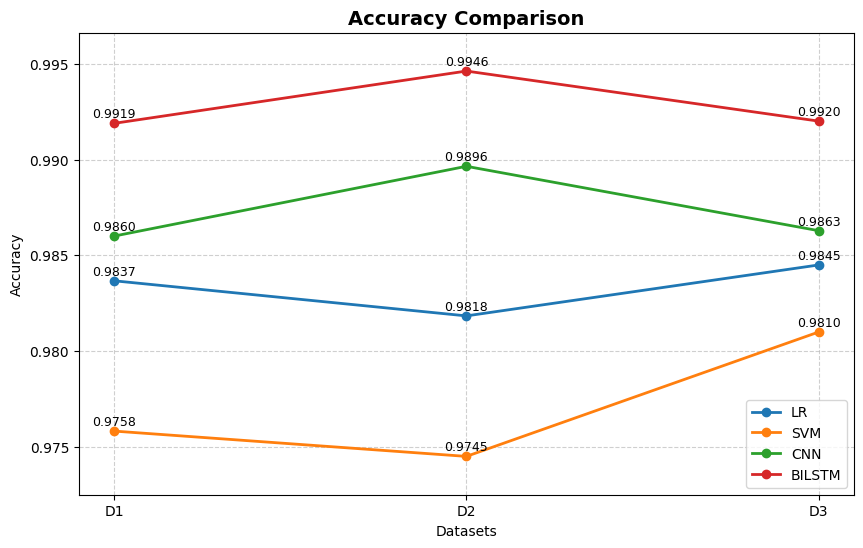

In [17]:
plot_metric(0, "Accuracy Comparison", "Accuracy")

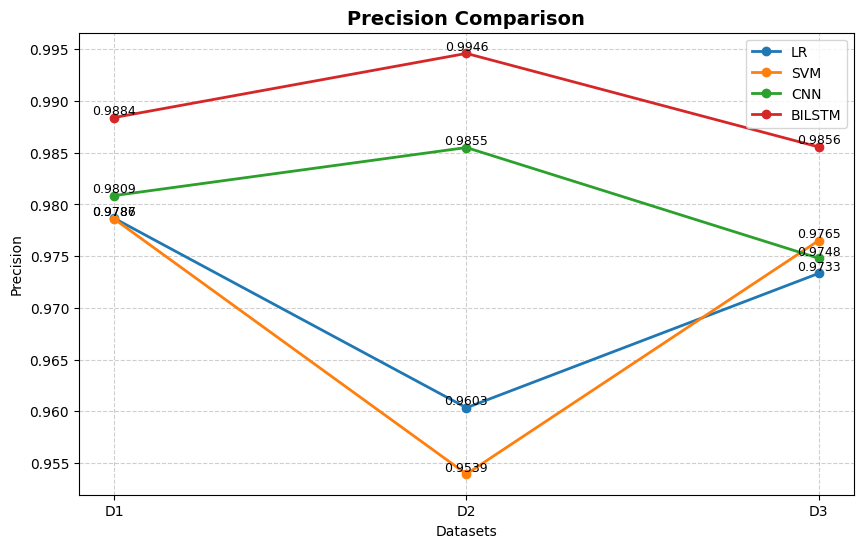

In [18]:
plot_metric(1, "Precision Comparison", "Precision")

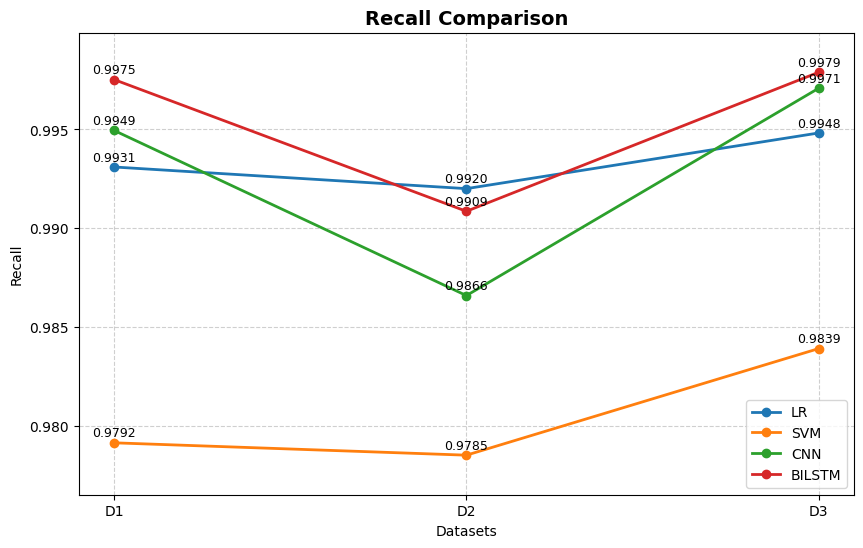

In [19]:
plot_metric(2, "Recall Comparison", "Recall")

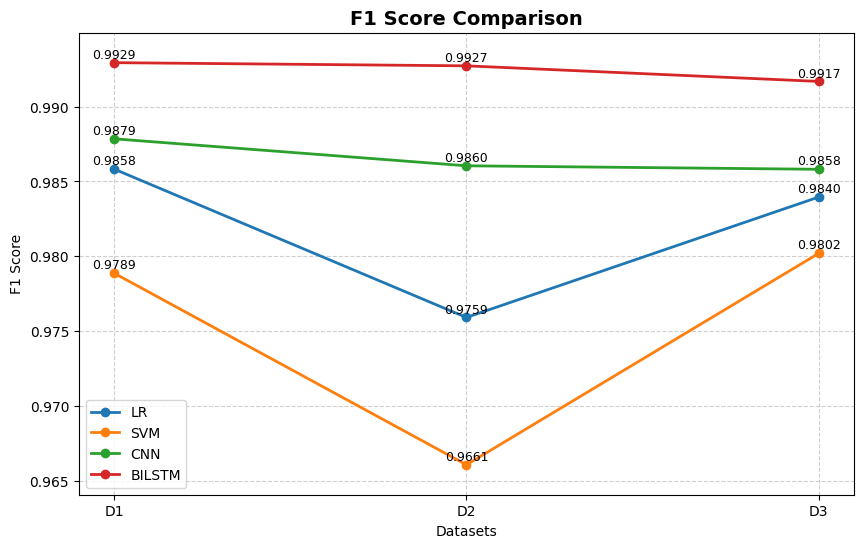

In [20]:
plot_metric(3, "F1 Score Comparison", "F1 Score")

In [21]:
avg_results = pd.DataFrame({
    "Model": ["LR","SVM","CNN","CNN+BiLSTM"],
    "Accuracy": [np.mean([r[m][0] for r in results]) for m in models],
    "Precision": [np.mean([r[m][1] for r in results]) for m in models],
    "Recall": [np.mean([r[m][2] for r in results]) for m in models],
    "F1 Score": [np.mean([r[m][3] for r in results]) for m in models]
})

print("\nAVERAGE RESULTS:\n")
print(avg_results)


AVERAGE RESULTS:

        Model  Accuracy  Precision    Recall  F1 Score
0          LR  0.983337   0.970777  0.993312  0.981902
1         SVM  0.977114   0.969678  0.980535  0.975049
2         CNN  0.987312   0.980383  0.992879  0.986572
3  CNN+BiLSTM  0.992835   0.989517  0.995427  0.992451


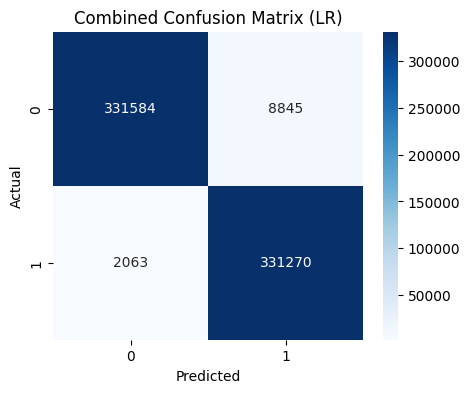

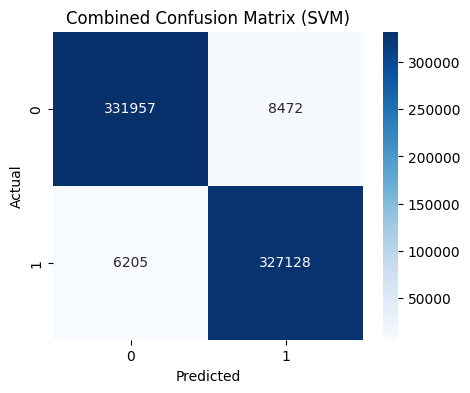

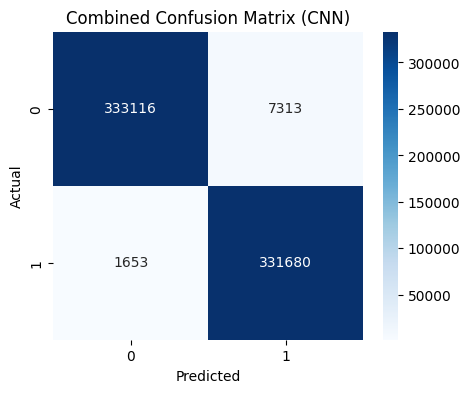

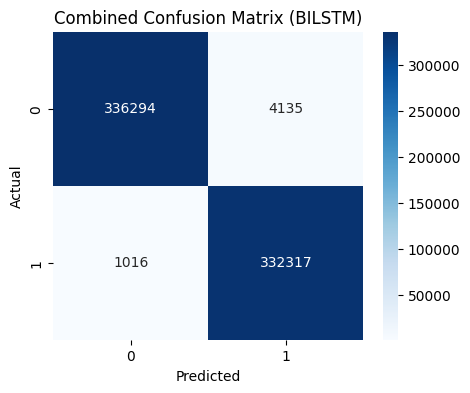

In [22]:
for model in models:
    cm_total = sum([r[f"cm_{model}"] for r in results])

    plt.figure(figsize=(5,4))
    sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Combined Confusion Matrix ({model.upper()})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

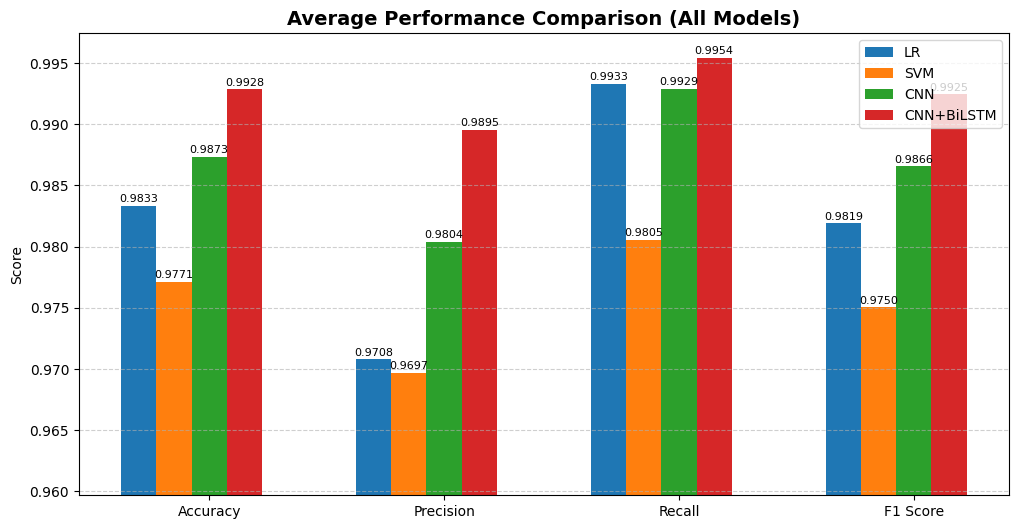

In [23]:
metrics = ["Accuracy","Precision","Recall","F1 Score"]
x = np.arange(len(metrics))
width = 0.15

plt.figure(figsize=(12,6))

all_vals = avg_results[metrics].values.flatten()

for i, model in enumerate(models):
    values = avg_results.iloc[i][metrics].values
    bars = plt.bar(x + i*width, values, width, label=avg_results.iloc[i]["Model"])

    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0003,
                 f"{bar.get_height():.4f}",
                 ha='center', fontsize=8)

plt.ylim(min(all_vals) - 0.01, max(all_vals) + 0.002)

plt.xticks(x + width*2, metrics)
plt.title("Average Performance Comparison (All Models)", fontsize=14, fontweight='bold')
plt.ylabel("Score")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()